# 02 — Training: Layer 1 (Utility) Classifier

| | |
|---|---|
| **Project** | Public Pulse |
| **Pipeline stage** | Layer 1 — Utility / Gatekeeper (`VALID` vs `NOISE`) |
| **Notebook role** | Fine-tuning only — data prep and final evaluation happen elsewhere |
| **Owner** | Thrithwaka Preethi Shakya |
| **Upstream input** | `data/splits/layer1/train.csv`, `data/splits/layer1/val.csv` (from `01_data_preparation.ipynb`) |
| **Downstream consumer** | `03_evaluation.ipynb` (teammate) — uses the checkpoint this notebook produces against the still-untouched test set |
| **Base model** | `xlm-roberta-base` (multilingual, SentencePiece tokenizer) |
| **Random seed** | 42 (fixed throughout) |

## Purpose

Fine-tunes `xlm-roberta-base` into a binary `VALID`/`NOISE` classifier on the prepared
Layer 1 training data. This notebook does **not** touch `data/splits/layer1/test.csv` —
that file is reserved exclusively for `03_evaluation.ipynb`. Any metrics shown here are
**validation-set sanity checks**, not the project's final reported performance.

## How to Read This Notebook

Written for someone with no prior context on this project. Every configuration choice is
explained where it's made, not assumed. As in `01_data_preparation.ipynb`, we do not
target or claim 100% accuracy anywhere in this notebook — the standard here is a
reproducible training run, honest per-class validation metrics, and a clearly justified
checkpoint hand-off to evaluation.

## 1. Compute Requirements & Environment

**Fine-tuning a 270M-parameter transformer is meaningfully more compute-intensive than
the inference-only work in earlier notebooks.** On CPU-only hardware, a full training run
over several epochs can realistically take many hours rather than minutes. If you're
running this on a laptop without a dedicated GPU, we strongly recommend running this
specific notebook on a free-GPU environment instead — **Google Colab (free T4 GPU)** or
**Kaggle Notebooks (free GPU quota)** are both zero-cost options that will cut training
time from hours to minutes. The rest of the project (data prep, everything else) doesn't
need this — only the actual `trainer.train()` step below does.

The cell below detects what you're running on and adjusts settings (mixed-precision
training) automatically — but it can't make CPU-only training fast, only tell you
honestly what to expect.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Points directly at your uploaded project root -- replace the PROJECT_ROOT
# line in Section 2 of the notebook with this instead of the relative "../../" version
PROJECT_ROOT = Path("/content/drive/MyDrive/public-pulse-srilanka")

assert PROJECT_ROOT.exists(), f"Project folder not found at {PROJECT_ROOT} -- check the folder name/path in your Drive."

print("Project root:", PROJECT_ROOT.resolve())
print("Contents:")
for item in sorted(PROJECT_ROOT.iterdir()):
    print(" -", item.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/public-pulse-srilanka
Contents:
 - .git
 - .github
 - .gitignore
 - Dockerfile
 - README.md
 - api
 - configs
 - dashboard
 - data
 - deployment
 - docs
 - models
 - notebooks
 - pyproject.toml
 - requirements.txt
 - results
 - scripts
 - src
 - tests


In [2]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device detected: {device}")

if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print("Mixed-precision (fp16) training will be enabled automatically below.")
else:
    print("WARNING: No GPU detected. Training will run on CPU and will be slow --")
    print("realistically hours for the full training run below, not minutes.")
    print("Strongly consider switching to Google Colab (free T4 GPU) or Kaggle for this notebook.")

Device detected: cuda
GPU: Tesla T4
Mixed-precision (fp16) training will be enabled automatically below.


## 2. Setup, Imports & Reproducibility

Seeds are set across every source of randomness we use (`random`, `numpy`, `torch`, and
the Hugging Face `Trainer`'s internal seeding) — without this, re-running this notebook
could produce a meaningfully different model each time, which would make the checkpoint
handed to `03_evaluation.ipynb` non-reproducible.

In [3]:
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
set_seed(RANDOM_STATE)  # covers Trainer-internal RNG usage as well

# ---- Paths ----
#PROJECT_ROOT = Path("../../")  # this notebook lives in notebooks/06_layer1_utility/
SPLITS_DIR = PROJECT_ROOT / "data" / "splits" / "layer1"
MODEL_DIR = PROJECT_ROOT / "models" / "layer1_utility"
CHECKPOINTS_DIR = MODEL_DIR / "checkpoints"
RUN_OUTPUT_DIR = MODEL_DIR / "_training_run"   # intermediate epoch checkpoints -- not the final promoted model
RESULTS_TRAINING_DIR = PROJECT_ROOT / "results" / "training_curves"
RESULTS_CM_DIR = PROJECT_ROOT / "results" / "confusion_matrices"

for d in [CHECKPOINTS_DIR, RUN_OUTPUT_DIR, RESULTS_TRAINING_DIR, RESULTS_CM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "xlm-roberta-base"
MAX_SEQ_LENGTH = 256  # see Section 4 -- corrected from 128 after 01_data_preparation.ipynb
                       # found 2.18% truncation at 128 against real data

print("Train/val source:", SPLITS_DIR.resolve())
print("Checkpoints will be saved to:", CHECKPOINTS_DIR.resolve())

Train/val source: /content/drive/MyDrive/public-pulse-srilanka/data/splits/layer1
Checkpoints will be saved to: /content/drive/MyDrive/public-pulse-srilanka/models/layer1_utility/checkpoints


## 3. Load Prepared Data (from `01_data_preparation.ipynb`)

Loading the already-cleaned, already-split, already-verified data — no cleaning or
splitting logic should exist in this notebook. If any of the assertions below fail, that
means the upstream contract from `01_data_preparation.ipynb` was broken (e.g. someone
re-ran that notebook with different settings) and this notebook should not proceed.

In [4]:
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("SPLITS_DIR:", SPLITS_DIR.resolve())
print("SPLITS_DIR exists:", SPLITS_DIR.exists())
print("train.csv exists:", (SPLITS_DIR / "train.csv").exists())

PROJECT_ROOT: /content/drive/MyDrive/public-pulse-srilanka
SPLITS_DIR: /content/drive/MyDrive/public-pulse-srilanka/data/splits/layer1
SPLITS_DIR exists: True
train.csv exists: True


In [5]:
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df = pd.read_csv(SPLITS_DIR / "val.csv")

print(f"Train: {len(train_df)} rows")
print(f"Val:   {len(val_df)} rows")
print()
print("Train class balance:")
print(train_df["layer1_utility_label"].value_counts(normalize=True).round(3) * 100)
print()
print("Val class balance:")
print(val_df["layer1_utility_label"].value_counts(normalize=True).round(3) * 100)

# Defensive checks -- fail loudly if the upstream contract is broken
assert train_df["layer1_utility_label"].isna().sum() == 0, "Missing labels in train set"
assert val_df["layer1_utility_label"].isna().sum() == 0, "Missing labels in val set"
assert set(train_df["layer1_utility_label"].unique()) <= {"VALID", "NOISE"}, "Unexpected label values in train set"
print("\nUpstream data contract verified.")

Train: 6503 rows
Val:   1393 rows

Train class balance:
layer1_utility_label
VALID    82.7
NOISE    17.3
Name: proportion, dtype: float64

Val class balance:
layer1_utility_label
VALID    82.8
NOISE    17.2
Name: proportion, dtype: float64

Upstream data contract verified.


## 4. Language & Tokenizer Considerations

**Why XLM-RoBERTa specifically:** this dataset code-switches freely between Sinhala
(native script), Singlish (romanized Sinhala), and English, often within a single
comment. XLM-RoBERTa's SentencePiece tokenizer is trained on 100 languages and uses
subword segmentation rather than word-level tokenization — meaning it doesn't require
knowing word boundaries ahead of time (which matters for Sinhala, where informal text
doesn't always separate words the way English does) and doesn't break down when a single
comment switches scripts mid-sentence.

**Why `xlm-roberta-base`, not `xlm-roberta-large`:** the base model (270M parameters) is
the right choice for a project at this data scale (~7,700 valid Layer 1 examples) and
compute budget (free-tier/personal hardware). The large variant needs substantially more
compute and data to realize its advantage over base, and would make free-tier deployment
(Hugging Face Spaces CPU tier) significantly slower for a marginal accuracy gain at this
scale.

**Confirming tokenizer behavior on our actual data** (reusing the check from
`01_data_preparation.ipynb`, now against the model we're about to train):

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = [
    "ඔන්න පටන් ගත්තා...හිරුගේ හෙළුව",           # Sinhala script
    "Pala hu... Yanda. Rata vinasa karapu haththa",  # Singlish
    "Too many Ads",                                    # English
    "Tik tok මෑණිවරු පරාදයි😂",                        # Mixed + emoji
]
for text in sample_texts:
    tokens = tokenizer.tokenize(text)
    print(f"{text!r}\n  -> {len(tokens)} tokens: {tokens}\n")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


'ඔන්න පටන් ගත්තා...හිරුගේ හෙළුව'
  -> 9 tokens: ['▁ඔන්න', '▁පටන්', '▁ගත්තා', '...', 'හි', 'රු', 'ගේ', '▁හෙ', 'ළුව']

'Pala hu... Yanda. Rata vinasa karapu haththa'
  -> 13 tokens: ['▁Pala', '▁hu', '...', '▁Yan', 'da', '.', '▁Rata', '▁vina', 'sa', '▁kara', 'pu', '▁ha', 'ththa']

'Too many Ads'
  -> 4 tokens: ['▁Too', '▁many', '▁Ad', 's']

'Tik tok මෑණිවරු පරාදයි😂'
  -> 11 tokens: ['▁Tik', '▁tok', '▁ම', 'ෑ', 'ණි', 'වරු', '▁ප', 'රා', 'ද', 'යි', '😂']



**`MAX_SEQ_LENGTH = 256`** (set in Section 2): `01_data_preparation.ipynb` found the
original default of 128 caused 2.18% truncation against real training data, with a 99th
percentile of 183 tokens. 256 comfortably covers that with margin, while staying well
under XLM-RoBERTa's hard 512-token architectural limit. A small number of extreme outlier
comments (the longest observed was 1,222 tokens) will still be truncated at 256 -- this is
an accepted, documented edge case, not an oversight.

## 5. Label Encoding

Defines the canonical label map for Layer 1 and saves it alongside the model artifacts —
this file is what `03_evaluation.ipynb` (and later, the inference cascade) will use to
translate the model's numeric output back into `VALID`/`NOISE`.

In [7]:
label2id = {"VALID": 0, "NOISE": 1}
id2label = {v: k for k, v in label2id.items()}

MODEL_DIR.mkdir(parents=True, exist_ok=True)
with open(MODEL_DIR / "label_map.json", "w") as f:
    json.dump(label2id, f, indent=2)

print("Label map:", label2id)
print("Saved to:", MODEL_DIR / "label_map.json")

train_df["label"] = train_df["layer1_utility_label"].map(label2id)
val_df["label"] = val_df["layer1_utility_label"].map(label2id)

Label map: {'VALID': 0, 'NOISE': 1}
Saved to: /content/drive/MyDrive/public-pulse-srilanka/models/layer1_utility/label_map.json


## 6. Tokenization & Dataset Construction

Uses truncation (to `MAX_SEQ_LENGTH`) but **dynamic padding** rather than fixed padding —
each batch is padded only to the length of its longest sequence, not to 256 every time.
This is standard practice: it noticeably speeds up training since most comments are much
shorter than the 256 cap (median was 13 tokens per `01_data_preparation.ipynb`), and
`DataCollatorWithPadding` (Section 8) handles this automatically per-batch.

In [8]:
def tokenize_function(examples):
    return tokenizer(
        examples["text_raw"],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        # no fixed padding here -- DataCollatorWithPadding pads dynamically per batch
    )

train_dataset = Dataset.from_pandas(train_df[["text_raw", "label"]].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[["text_raw", "label"]].reset_index(drop=True))

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

print(train_dataset)
print()
print("Example tokenized row:")
print(train_dataset[0])

Map:   0%|          | 0/6503 [00:00<?, ? examples/s]

Map:   0%|          | 0/1393 [00:00<?, ? examples/s]

Dataset({
    features: ['text_raw', 'label', 'input_ids', 'attention_mask'],
    num_rows: 6503
})

Example tokenized row:
{'text_raw': 'බැරිද පෝලිමක් දාන්න එවන්න \r\nපින්සිද්ද වෙනවා අයියේ', 'label': 0, 'input_ids': [0, 38187, 1859, 81340, 6513, 66758, 82593, 8895, 44086, 167432, 11510, 29886, 32085, 125913, 1188, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


## 7. Model Initialization

`num_labels=2` for the binary Layer 1 head. `id2label`/`label2id` are passed directly
into the model config so the saved checkpoint is self-documenting — anyone loading it
later (including the inference cascade) can see what the output indices mean without
needing this notebook.

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)
model.to(device)

print(f"Model loaded on: {device}")
print(f"Total parameters: {model.num_parameters():,}")

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on: cuda
Total parameters: 278,045,186


## 8. Evaluation Metrics

**We use macro-F1, not accuracy, as the primary metric for model selection** — this
matters even though Layer 1's ~83/17 class split is far less imbalanced than the layers
we chose not to train (Layer 3, sarcasm). Macro-F1 weights both classes equally regardless
of their frequency, so a model that quietly gets worse at detecting `NOISE` (the minority
class) while accuracy stays flat would still be caught here. Full precision/recall/F1 per
class is also reported at every evaluation step, not just the summary number.

In [10]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    report = classification_report(
        labels, predictions, target_names=["VALID", "NOISE"], output_dict=True, zero_division=0
    )

    return {
        "accuracy": report["accuracy"],
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "f1_valid": report["VALID"]["f1-score"],
        "f1_noise": report["NOISE"]["f1-score"],
        "precision_noise": report["NOISE"]["precision"],
        "recall_noise": report["NOISE"]["recall"],
    }

## 9. Training Configuration

Standard fine-tuning hyperparameters for this model/data scale (`configs/layer1.yaml`
documents these as the project defaults):
- **Learning rate 2e-5** — the standard starting point for fine-tuning RoBERTa-family
  models; higher risks destabilizing the pretrained weights, lower risks under-fitting
  in a small number of epochs.
- **4 epochs** — enough for a dataset this size to converge without the model starting to
  memorize the training set; `load_best_model_at_end` protects against overfitting past
  this if the best epoch turns out to be earlier.
- **Weighted loss: not used.** `01_data_preparation.ipynb` confirmed both classes exceed
  the project's good-performance data threshold — class weighting is a documented option
  for future layers with genuine imbalance (e.g. Layer 4's sarcasm class), not needed here.
- **`fp16` enabled automatically if a GPU is available** (Section 1) — halves memory use
  and speeds up training on compatible hardware, with no effect if running on CPU.

In [11]:
import transformers
print(transformers.__version__)

4.53.0


In [12]:
training_args = TrainingArguments(
    output_dir=str(RUN_OUTPUT_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,          # keep only the 2 most recent epoch checkpoints on disk
    fp16=(device == "cuda"),
    seed=RANDOM_STATE,
    report_to="none",           # no external experiment-tracking dependency required
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

## 10. Train

This is the compute-intensive step described in Section 1. Progress (loss and validation
metrics per epoch) prints below as it runs.

In [13]:
train_result = trainer.train()
print("Training complete.")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Valid,F1 Noise,Precision Noise,Recall Noise
1,0.170500,0.040565,0.991385,0.984848,0.994801,0.974895,0.978992,0.970833
2,0.047100,0.035730,0.992103,0.985899,0.995252,0.976546,1.000000,0.954167
3,0.034200,0.030149,0.993539,0.988617,0.996102,0.981132,0.987342,0.975000
4,0.026700,0.026320,0.994975,0.991205,0.996963,0.985447,0.983402,0.987500


Training complete.
TrainOutput(global_step=1628, training_loss=0.06962504375185954, metrics={'train_runtime': 501.1796, 'train_samples_per_second': 51.902, 'train_steps_per_second': 3.248, 'total_flos': 1481314727788020.0, 'train_loss': 0.06962504375185954, 'epoch': 4.0})


## 11. Training Curves

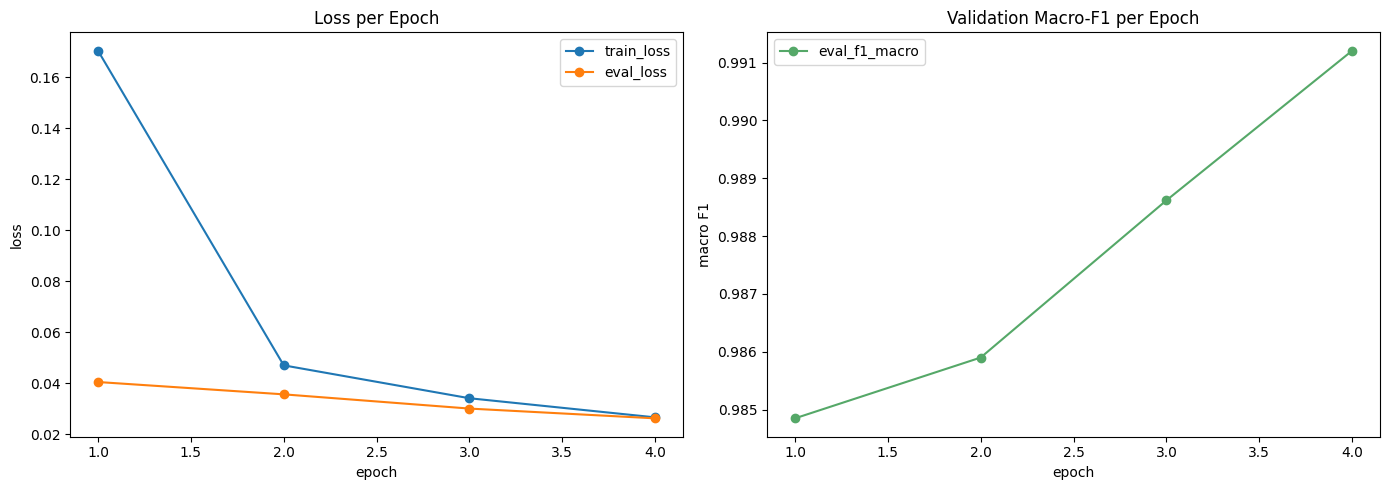

In [14]:
log_history = trainer.state.log_history

train_loss = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e]
eval_loss = [(e["epoch"], e["eval_loss"]) for e in log_history if "eval_loss" in e]
eval_f1 = [(e["epoch"], e["eval_f1_macro"]) for e in log_history if "eval_f1_macro" in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if train_loss:
    axes[0].plot(*zip(*train_loss), label="train_loss", marker="o")
if eval_loss:
    axes[0].plot(*zip(*eval_loss), label="eval_loss", marker="o")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

if eval_f1:
    axes[1].plot(*zip(*eval_f1), label="eval_f1_macro", marker="o", color="#55A868")
axes[1].set_title("Validation Macro-F1 per Epoch")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("macro F1")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_TRAINING_DIR / "layer1_training_curves.png", dpi=150)
plt.show()

## 12. Save the Promoted Checkpoint

`load_best_model_at_end=True` (Section 9) means `trainer.model` already holds the
best-performing epoch by validation macro-F1, not necessarily the last epoch trained.
We save **only this promoted checkpoint** to `models/layer1_utility/checkpoints/` — the
intermediate per-epoch checkpoints in `_training_run/` are training artifacts, not
production models, and can be deleted once this cell confirms the promoted save succeeded.

In [15]:
best_model_dir = CHECKPOINTS_DIR / "best_model"
best_model_dir.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(best_model_dir))
tokenizer.save_pretrained(str(best_model_dir))

# Record which epoch/metric this checkpoint corresponds to, for traceability
best_metric_value = trainer.state.best_metric
metadata = {
    "base_model": MODEL_NAME,
    "max_seq_length": MAX_SEQ_LENGTH,
    "best_metric": "f1_macro",
    "best_metric_value": best_metric_value,
    "random_seed": RANDOM_STATE,
    "train_rows": len(train_df),
    "val_rows": len(val_df),
}
with open(MODEL_DIR / "training_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Promoted checkpoint saved to:", best_model_dir.resolve())
print("Best validation macro-F1:", best_metric_value)
print()
print("Intermediate per-epoch checkpoints remain in:", RUN_OUTPUT_DIR.resolve())
print("These can be safely deleted now that the best checkpoint has been promoted.")

Promoted checkpoint saved to: /content/drive/MyDrive/public-pulse-srilanka/models/layer1_utility/checkpoints/best_model
Best validation macro-F1: 0.9912050545456186

Intermediate per-epoch checkpoints remain in: /content/drive/MyDrive/public-pulse-srilanka/models/layer1_utility/_training_run
These can be safely deleted now that the best checkpoint has been promoted.


## 13. Validation Set Sanity Check

**This is not the project's final evaluation.** This is a sanity check on the validation
set (which the training process already saw and used for model selection) so we have a
reasonable expectation of performance before handing off to `03_evaluation.ipynb`, which
runs the real, held-out test-set evaluation. Treat the numbers below as directional, not
final.

In [16]:
val_predictions = trainer.predict(val_dataset)
val_preds = np.argmax(val_predictions.predictions, axis=-1)
val_labels = val_predictions.label_ids

print(classification_report(val_labels, val_preds, target_names=["VALID", "NOISE"], zero_division=0))

              precision    recall  f1-score   support

       VALID       1.00      1.00      1.00      1153
       NOISE       0.98      0.99      0.99       240

    accuracy                           0.99      1393
   macro avg       0.99      0.99      0.99      1393
weighted avg       0.99      0.99      0.99      1393



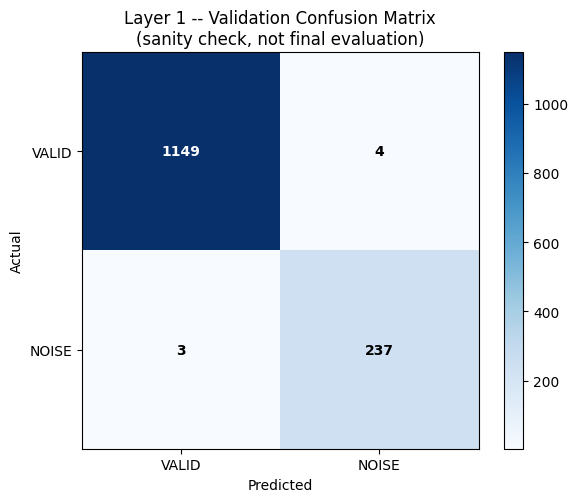

In [17]:
cm = confusion_matrix(val_labels, val_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["VALID", "NOISE"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["VALID", "NOISE"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Layer 1 -- Validation Confusion Matrix\n(sanity check, not final evaluation)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontweight="bold")
plt.colorbar(im)
plt.tight_layout()
plt.savefig(RESULTS_CM_DIR / "layer1_validation_confusion_matrix.png", dpi=150)
plt.show()

## 14. Notebook Summary

### What was done
1. Detected compute environment (GPU/CPU) and configured mixed-precision training accordingly
2. Loaded and verified the prepared train/val splits from `01_data_preparation.ipynb`
   against their expected contract (no missing labels, no unexpected values)
3. Confirmed XLM-RoBERTa tokenizer behavior on real Sinhala/Singlish/English/emoji
   examples, and corrected `max_seq_length` to 256 based on `01_data_preparation.ipynb`'s
   truncation finding
4. Built and saved the canonical Layer 1 label map
5. Tokenized train/val data with truncation and dynamic (not fixed) padding
6. Fine-tuned `xlm-roberta-base` for 4 epochs, selecting the best checkpoint by
   validation macro-F1 (not accuracy) — no class weighting needed given the confirmed
   class balance from data preparation
7. Saved training curves and the promoted best checkpoint, with training metadata for
   traceability
8. Ran a validation-set sanity check (classification report + confusion matrix) —
   explicitly **not** the project's final evaluation

### Outputs produced (exact paths)
| File | Contents |
|---|---|
| `models/layer1_utility/checkpoints/best_model/` | Promoted checkpoint: model weights, config, tokenizer |
| `models/layer1_utility/label_map.json` | `{"VALID": 0, "NOISE": 1}` |
| `models/layer1_utility/training_metadata.json` | Base model, seq length, best metric, seed, data sizes |
| `results/training_curves/layer1_training_curves.png` | Loss + validation F1 per epoch |
| `results/confusion_matrices/layer1_validation_confusion_matrix.png` | Validation sanity-check confusion matrix |

### Key results
[Fill in after running: best validation macro-F1, per-class precision/recall/F1 from
Section 13, and total training time/device used — this section should be completed with
real numbers before handing off, not left as a placeholder.]

## 15. Handover Notes — For the `03_evaluation.ipynb` Owner

**What to load:**
```python
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("models/layer1_utility/checkpoints/best_model")
tokenizer = AutoTokenizer.from_pretrained("models/layer1_utility/checkpoints/best_model")
```
Label map: `models/layer1_utility/label_map.json`. Training config/context:
`models/layer1_utility/training_metadata.json`.

**What to evaluate against:** `data/splits/layer1/test.csv` — this file has not been
touched by this notebook or `01_data_preparation.ipynb` since it was created. This is the
**first and only time** it should be used.

**What NOT to do:** don't retrain, don't fine-tune further, don't peek at test-set
performance and come back to this notebook to "improve" the model based on it — that
would invalidate the test set as an unbiased measure, the same principle protected
throughout this pipeline.

**What to report:** full classification report (precision/recall/F1 per class) and
confusion matrix on the test set, same format as Section 13's validation sanity check —
so the two are directly comparable. If test-set macro-F1 is meaningfully lower than the
validation macro-F1 recorded in `training_metadata.json`, that's worth flagging back to
this notebook's owner as a possible sign of overfitting to the validation set during
model selection.

**Known caveats to carry forward:**
- The English-language NOISE-rate discrepancy flagged in `01_data_preparation.ipynb`
  (Section 9.2) is still unresolved — consider breaking down test-set performance by
  `language_detected` if that column is available in your evaluation setup.
- Model selection here used macro-F1 across a ~83/17 class split; if evaluation reveals
  the model is meaningfully weaker on `NOISE` specifically, that's the class to
  investigate first, not `VALID`.